# Разработка A/B-тестирования и анализ результатов

- Автор: Васильев Арсений
- Дата: 18.08.2026

Продукт - развлекательное приложение с лентой коротких видео. 
Бизнес-модель строится на балансе между удержанием пользователей (через качественный контент) и монетизацией (реклама для бесплатных пользователей и подписка).

**Проблема:** команда ML разработала новый алгоритм ранжирования ленты. Гипотеза заключается в том, что персонализация станет точнее, и пользователи будут проводить больше времени в приложении, просматривая больше контента за одну сессию.

**Цель анализа:** оценить влияние нового алгоритма на вовлеченность пользователей через A/B-тест, проверить корректность проведения эксперимента и сделать выводы о целесообразности обновления.

## Описание данных

Для анализа использованы логи пользовательских сессий. Данные разделены на два периода:
1. `sessions_project_history.csv` - период до запуска теста (август-сентябрь 2025). Используются для расчета базовых метрик и планирования параметров теста.
2. `sessions_project_test.csv` - период проведения A/B-теста (октябрь-ноябрь 2025). Содержат разметку по группам.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` - идентификатор пользователя;

- `session_id` - идентификатор сессии в приложении;

- `session_date` - дата сессии;

- `session_start_ts` - дата и время начала сессии;

- `install_date` - дата установки приложения;

- `session_number` - порядковый номер сессии для конкретного пользователя;

- `registration_flag` - является ли пользователь зарегистрированным;

- `page_counter` - количество просмотренных страниц во время сессии;

- `region` - регион пользователя;

- `device` - тип устройства пользователя;

- `test_group` - тестовая группа (в таблице с историческими данными этого столбца нет).

## Содержание

- [1. Работа с историческими данными (EDA)](#1.-Работа-с-историческими-данными-(EDA)) 
  - [1.1 Загрузка исторических данных](#1.1.-Загрузка-исторических-данных) 
  - [1.2 Знакомство с данными](#1.2.-Знакомство-с-данными) 
  - [1.3 Анализ числа регистраций](#1.3.-Анализ-числа-регистраций) 
  - [1.4 Анализ числа просмотренных страниц](#1.4.-Анализ-числа-просмотренных-страниц) 
  - [1.5 Доля успешных первых сессий](#1.5.-Доля-пользователей,-просмотревших-более-четырёх-страниц) 
- [2. Подготовка к тесту](#2.-Подготовка-к-тесту) 
  - [2.1 Расчёт размера выборки](#2.1.-Расчёт-размера-выборки) 
  - [2.2 Расчёт длительности A/B-теста](#2.2.-Расчёт-длительности-A/B-теста) 
- [3. Мониторинг A/B-теста](#3.-Мониторинг-А/В-теста) 
  - [3.1 Проверка распределения пользователей](#3.1.-Проверка-распределения-пользователей) 
  - [3.2 Проверка пересечений пользователей](#3.2.-Проверка-пересечений-пользователей) 
  - [3.3 Равномерность разделения по устройствам](#3.3.-Равномерность-разделения-пользователей-по-устройствам) 
  - [3.4 Равномерность распределения по регионам](#3.4.-Равномерность-распределения-пользователей-по-регионам) 
  - [3.5 Вывод после проверки A/B-теста](#3.5.-Вывод-после-проверки-A/B-теста) 
- [4. Проверка результатов A/B-теста](#4.-Проверка-результатов-A/B-теста) 
  - [4.1 Подготовка данных теста](#4.1.-Получение-результатов-теста-и-подсчёт-основной-метрики) 
  - [4.2 Формулировка гипотез и определение метрик](#4.2.-Формулировка-гипотез-и-определение-метрик)
  - [4.3 Сравнение долей успешных сессий](#4.3.-Сравнение-доли-успешных-первых-сессий) 
  - [4.4 Проверка статистической значимости](#4.4.-Насколько-статистически-значимо-изменение-ключевой-метрики) 
  - [4.5 Итоговые выводы и рекомендации](#4.5.-Вывод-по-результатам-A/B-эксперимента) 

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

Загрузим все необходимые библиотеки и файл `sessions_project_history.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from statsmodels.stats.proportion import proportions_ztest

In [2]:
sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

# сразу приведем даты к datetime
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])
sessions_history['install_date'] = pd.to_datetime(sessions_history['install_date'])
sessions_history['session_start_ts'] = pd.to_datetime(sessions_history['session_start_ts'])
                                                      
display(sessions_history.head())
display(sessions_history.info())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   user_id            435924 non-null  object        
 1   session_id         435924 non-null  object        
 2   session_date       435924 non-null  datetime64[ns]
 3   session_start_ts   435924 non-null  datetime64[ns]
 4   install_date       435924 non-null  datetime64[ns]
 5   session_number     435924 non-null  int64         
 6   registration_flag  435924 non-null  int64         
 7   page_counter       435924 non-null  int64         
 8   region             435924 non-null  object        
 9   device             435924 non-null  object        
dtypes: datetime64[ns](3), int64(3), object(4)
memory usage: 33.3+ MB


None

#### 1.2. Знакомство с данными

Выведем все данные для пользователя с наибольшим количеством сессий.

In [3]:
# считаем колво сессий для каждого пользователя
session_counts = sessions_history.groupby('user_id')['session_id'].nunique().reset_index()
session_counts = session_counts.sort_values('session_id', ascending=False)

# находим макс колво сессий и отбираем таких пользователей
max_sessions = session_counts['session_id'].max()
top_user = session_counts[session_counts['session_id'] == max_sessions]

sessions_history[sessions_history['user_id'].isin(top_user['user_id'].head(1))]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций

Регистрация - это первое действие пользователя в приложении. Она показывает, что человек заинтересовался контентом и готов возвращаться.

Посмотрим, как менялось число новых регистраций по дням. Считаем регистрацию, как уникальное событие: один пользователь = одна регистрация в день. По сути, это аналог DAU, но только для регистраций.

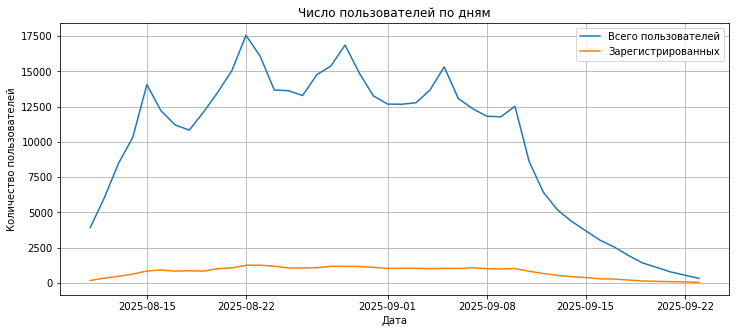

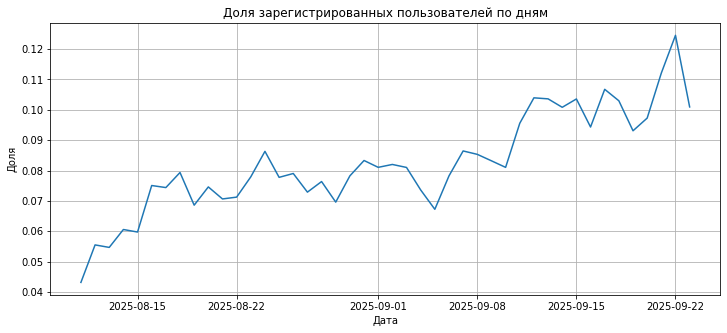

In [4]:
# считаем что у пользователя одна сессия в день
daily_users = sessions_history.drop_duplicates(subset=['user_id', 'session_date'])

# считаем общее число пользователей и число зарегистрированных по дням
daily_stats = daily_users.groupby('session_date').agg(
    total_users=('user_id', 'nunique'),
    registered_users=('registration_flag', 'sum')
).reset_index()

# график 1 - абсолютные значения
plt.figure(figsize=(12, 5))
plt.plot(daily_stats['session_date'], daily_stats['total_users'], label='Всего пользователей')
plt.plot(daily_stats['session_date'], daily_stats['registered_users'], label='Зарегистрированных')
plt.title('Число пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid()
plt.legend()
plt.show()

# график 2 - доля зарегистрированных
plt.figure(figsize=(12, 5))
plt.plot(daily_stats['session_date'], daily_stats['registered_users'] / daily_stats['total_users'])
plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.grid()
plt.show()

**Вывод:**

- **Регистрации:** число регистраций следует за общей динамикой трафика - быстрый рост в первую неделю, пик 22-23 августа, стабильное движение до 10 сентября и затем резкий спад. Динамика плавная, без аномальных выбросов.

- **Недельная сезонность:** заметны регулярные пики посещаемости по пятницам (15.08, 22.08, 29.08, 05.09) и спады в начале недели. Эти циклы важно учитывать при планировании теста - длительность эксперимента должна покрывать целые недели.

- **Доля зарегистрированных:** доля растёт с 4% в начале периода до 7-9% и достигает 12% в конце. Рост в конце периода вызван уменьшением числа наблюдений - при дневной посещаемости в несколько сотен пользователей доля становится нестабильной, поэтому выводы по этим дням ненадежны.

- **Планирования теста:** спад посещаемости после 10 сентября означает, что средний трафик завышает реальный приток. При расчёте длительности теста нужно учитывать недельную сезонность, иначе можно не набрать нужную выборку в запланированный срок.

#### 1.4. Анализ числа просмотренных страниц

Глубина просмотра - важный показатель вовлечённости. Чем больше страниц пользователь посмотрел за сессию, тем интереснее ему контент. Посмотрим распределение первых сессий по числу просмотренных страниц.

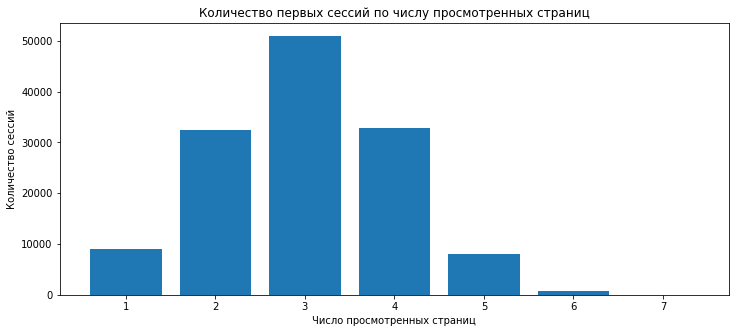

In [5]:
# оставляем только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# считаем количество сессий
page_counts = first_sessions['page_counter'].value_counts().sort_index()

# столбчатая диаграмма
plt.figure(figsize=(12, 5))
plt.bar(page_counts.index, page_counts.values)
plt.title('Количество первых сессий по числу просмотренных страниц')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.show()

**Вывод:**

- **Распределение:** первые сессии по числу просмотренных страниц распределены почти симметрично с центром в 3 страницах. Всего первых сессий за период - 134 039. Наиболее частый исход - 3 страницы: около 50 000 сессий. Вокруг него почти симметрично располагаются 2 страницы и 4 страницы по 32 000 сессий.

- **Крайние значения:** короткие сессии в 1 страницу - 9 000, эти пользователи ушли почти сразу. Глубокие сессии в 6-7 страниц - всего 1 000, сильное погружение в первой сессии случается редко. Большинство новых пользователей просматривают 2-4 страницы.

- **Связь с целевой метрикой:** сессий с 4 и более страницами (успешных по критерию продуктовой команды) - 41 628 из 134 039, то есть около 31%. Это базовый уровень метрики, от которого мы отталкивались при расчёте размера выборки.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц

Продуктовая команда считает, что если пользователь в первой сессии просмотрел 4 и более страниц, то это говорит об удовлетворённости контентом и качеством рекомендаций. Этот показатель станет нашей целевой метрикой для A/B-теста.

Посмотрим, как менялась доля успешных сессий по дням. Это поможет понять базовый уровень метрики и её стабильность.

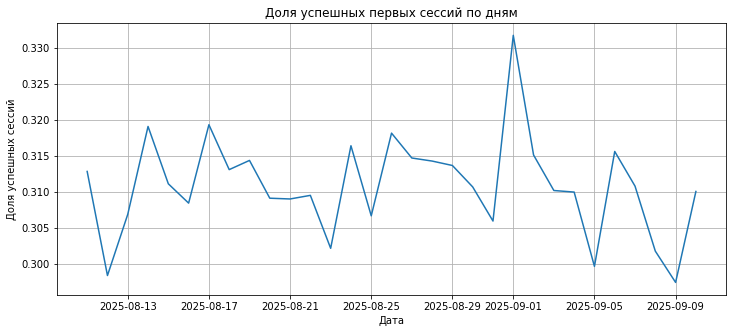

In [6]:
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

# оставляем только первые сессии и считаем долю успешных по дням
first_sessions = sessions_history[sessions_history['session_number'] == 1]
daily_good_share = first_sessions.groupby('session_date')['good_session'].mean()

# график доли успешных первых сессий по дням
plt.figure(figsize=(12, 5))
plt.plot(daily_good_share.index, daily_good_share.values)
plt.title('Доля успешных первых сессий по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')
plt.grid()
plt.show()

**Вывод:**

- **Уровень метрики:** доля успешных первых сессий (4+ страниц) в среднем за период составляет около 31%, значения почти всех дней лежат в диапазоне 29.7% - 32%.

- **Стабильность:** метрика колеблется вокруг постоянного уровня, это может говорить о стабильном качестве контента и рекомендаций для новых пользователей.

- **Цикличность и выбросы:** на графике есть небольшие колебания с периодом около недели и единичный выброс 01.09 (33.2%).

### 2. Подготовка к тесту

Перед запуском A/B-теста нужно определить его параметры: целевую метрику, размер выборки и длительность. Это необходимо, чтобы эксперимент был статистически корректным и мы могли обнаружить эффект, если он действительно есть.

#### 2.1. Расчёт размера выборки

Чтобы найти размер выборки используем параметры:
- Уровень значимости α = 0.05
- Мощность теста 1-β = 0.80
- Базовый уровень метрики p = 0.30
- Минимальный детектируемый эффект MDE = 3%

In [7]:
alpha = 0.05
beta = 0.2
power = 1 - beta
p = 0.3
mde = p * 0.03

effect_size = proportion_effectsize(p, p + mde)

power_analysis = NormalIndPower()

# расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Зная необходимый размер выборки и средний дневной трафик, можно оценить, сколько дней должен длиться эксперимент.

In [8]:
# среднее колво пользователей приложения в день
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# рассчитываем длительность теста в днях
test_duration = ceil(sample_size / (avg_daily_users / 2))

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

Перед анализом результатов нужно убедиться, что эксперимент проведен корректно. Проверим три главных пункта: баланс размеров групп, отсутствие пересечений между ними и равномерность распределения по устройствам и регионам.

#### 3.1. Проверка распределения пользователей

Первое, что нужно проверить - нет ли перекоса в размерах групп. Если в одной группе окажется значительно больше пользователей, это может исказить результаты теста.

Загрузим данные за первый день теста и сравним количество уникальных пользователей в группах A и B.

test_group
A    1477
B    1466
Name: user_id, dtype: int64
Процентная разница между группами: 0.74%


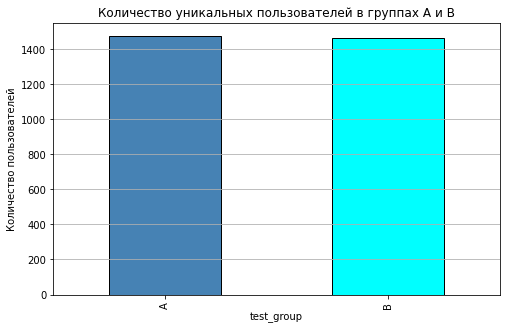

In [9]:
# загрузка данных за первый день теста
sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')

# колво уникальных пользователей в каждой группе
group_counts = sessions_test_part.groupby('test_group')['user_id'].nunique()
print(group_counts)

# расчёт процентной разницы
users_A = group_counts['A']
users_B = group_counts['B']
P = 100 * abs(users_A - users_B) / users_A
print(f'Процентная разница между группами: {P:.2f}%')

# визуализация
plt.figure(figsize=(8, 5))
group_counts.plot(kind='bar', color=['steelblue', 'cyan'], edgecolor='black')
plt.title('Количество уникальных пользователей в группах A и B')
plt.ylabel('Количество пользователей')
plt.grid(axis='y')
plt.show()

#### 3.2. Проверка пересечений пользователей

Важно убедиться, что каждый пользователь попал только в одну группу. Если кто-то оказался и в A, и в B одновременно - это техническая ошибка, которая сделает результаты неверными.

In [10]:
# множества уникальных пользователей в каждой группе
users_A = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])
users_B = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

# пересечение множеств
intersection = users_A.intersection(users_B)

print(f'Количество пользователей, попавших в обе группы: {len(intersection)}')

Количество пользователей, попавших в обе группы: 0


#### 3.3. Равномерность разделения пользователей по устройствам

Проверим, что пользователи равномерно распределены по типам устройств в обеих группах. Если, например, в тестовой группе окажется больше пользователей с iPhone, а в контрольной - с Android, это может повлиять на метрики.

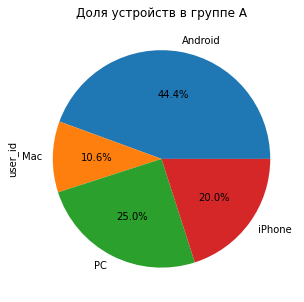

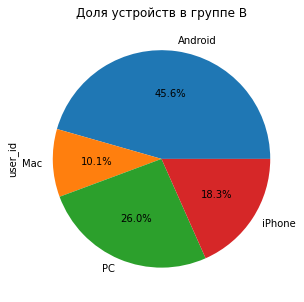

In [11]:
# число уникальных пользователей по каждому устройству в каждой группе
device_A = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('device')['user_id'].nunique()
device_B = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('device')['user_id'].nunique()

# переводим в доли
device_A = device_A / device_A.sum()
device_B = device_B / device_B.sum()

# график для группы A
plt.figure(figsize=(8, 5))
device_A.plot(kind='pie', autopct='%1.1f%%')
plt.title('Доля устройств в группе A')
plt.show()

# график для группы B
plt.figure(figsize=(8, 5))
device_B.plot(kind='pie', autopct='%1.1f%%')
plt.title('Доля устройств в группе B')
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам

Аналогично проверим распределение пользователей по регионам. Убедимся, что нет перекоса между группами.

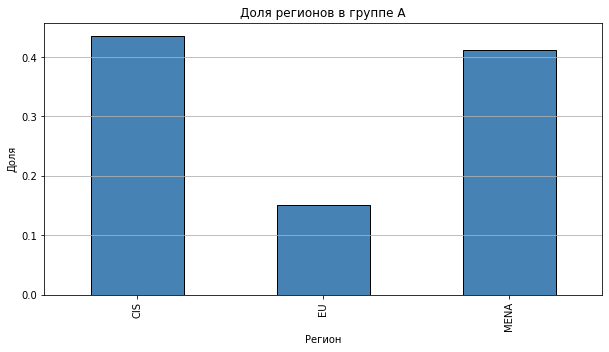

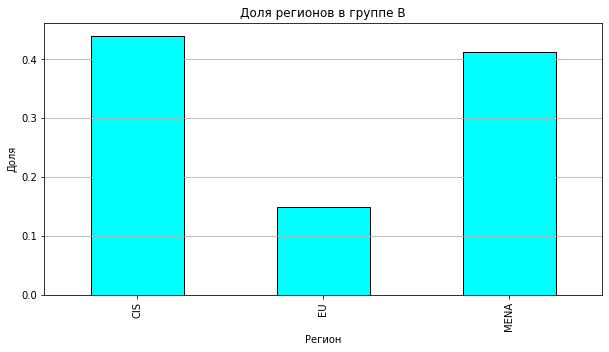

In [12]:
# число УНИКАЛЬНЫХ пользователей по каждому региону в каждой группе
region_A = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('region')['user_id'].nunique()
region_B = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('region')['user_id'].nunique()

# переводим в доли
region_A = region_A / region_A.sum()
region_B = region_B / region_B.sum()

# график для группы A
plt.figure(figsize=(10, 5))
region_A.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Доля регионов в группе A')
plt.xlabel('Регион')
plt.ylabel('Доля')
plt.grid(axis='y')
plt.show()

# график для группы B
plt.figure(figsize=(10, 5))
region_B.plot(kind='bar', color='cyan', edgecolor='black')
plt.title('Доля регионов в группе B')
plt.xlabel('Регион')
plt.ylabel('Доля')
plt.grid(axis='y')
plt.show()

#### 3.5. Вывод после проверки A/B-теста

1. **Распределение пользователей:** процентная разница в количестве уникальных пользователей между группами A и B менее 1% (0.74%) - это допустимая погрешность, группы сбалансированы по размеру.
2. **Независимость выборок:** пересечений пользователей между группами нет (0 пользователей), каждый пользователь попадает только в одну группу.
3. **Равномерность стратификации:** распределение пользователей по типам устройств и регионам в контрольной и тестовой группах визуально совпадает. Нет перекосов, которые могли бы исказить результаты эксперимента.

**Заключение:** A/B-тест проходит корректно. Нарушений логики сбора данных нет, выборки репрезентативны и независимы. Можно переходить к анализу итоговых результатов.

### 4. Проверка результатов A/B-теста

Тест завершён, теперь нужно проверить корректность его проведения и оценить, повлиял ли новый алгоритм на целевую метрику.

#### 4.1. Получение результатов теста и подсчёт основной метрики

Загрузим полные данные за весь период проведения A/B-теста и подготовим целевую метрику.

In [13]:
# загрузка данных за весь период теста
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

#### 4.2. Формулировка гипотез и определение метрик

Перед проверкой результатов сформулируем гипотезы и определим, какие метрики будем использовать.

**Гипотезы:**
- **Нулевая гипотеза ($H_0$):** новый алгоритм рекомендаций не влияет на вовлечённость пользователей. Доля успешных первых сессий в тестовой и контрольной группах одинакова $p_A = p_B$
- **Альтернативная гипотеза ($H_1$):** новый алгоритм рекомендаций увеличивает долю успешных первых сессий. Доля в тестовой группе выше, чем в контрольной $p_B > p_A$

**Метрики:**
- **Целевая метрика:** доля успешных первых сессий `good_session`, где пользователь просмотрел 4 и более страниц. Эта метрика показывает удовлетворённость контентом и качеством рекомендаций.
- **Прокси метрики:** средняя глубина просмотра `page_counter`, время, проведённое в сессии, конверсия в оформление подписки. Эти метрики косвенно подтверждают рост вовлечённости.
- **Барьерные метрики:** отток пользователей, количество ошибок, выручка от рекламы на пользователя (ARPU). Эти метрики гарантируют, что новый алгоритм не ухудшил пользовательский опыт и монетизацию.

#### 4.3. Сравнение доли успешных первых сессий

Посчитаем долю успешных первых сессий в каждой группе и оценим разницу между ними.

In [14]:
# оставляем только первые сессии
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

# считаем долю успешных первых сессий для каждой группы
group_metrics = first_sessions_test.groupby('test_group')['good_session'].mean()

print('Доли успешных первых сессий по группам:')
display(group_metrics)

# разница между группами
diff = group_metrics['B'] - group_metrics['A']
print(f'Абсолютная разница: {diff:.4f}')
print(f"Относительная разница: {(diff / group_metrics['A']) * 100:.2f}%")

Доли успешных первых сессий по группам:


test_group
A    0.315724
B    0.314673
Name: good_session, dtype: float64

Абсолютная разница: -0.0011
Относительная разница: -0.33%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

Разница между группами может быть случайной. Чтобы понять, является ли эффект статистически значимым, проведём Z-тест для сравнения долей.

In [15]:
# оставляем только первые сессии
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

# считаем колво успехов и общее число наблюдений в каждой группе
successes = first_sessions_test.groupby('test_group')['good_session'].sum()
nobs = first_sessions_test.groupby('test_group')['user_id'].count()

# Z-тест
stat, p_value = proportions_ztest(
    [successes['B'], successes['A']], 
    [nobs['B'], nobs['A']], 
    alternative='larger'
)

print(f'p-value: {p_value:.3f}')

if p_value < 0.05:
    print('Отклоняем нулевую гипотезу: новый алгоритм увеличивает долю успешных сессий')
else:
    print('Не отклоняем нулевую гипотезу: нет статистически значимого подтверждения роста доли успешных сессий')

p-value: 0.578
Не отклоняем нулевую гипотезу: нет статистически значимого подтверждения роста доли успешных сессий


#### 4.5. Вывод по результатам A/B-эксперимента

**Характеристики эксперимента:**
- Необходимый размер выборки: 41 040 пользователей на группу
- Средняя посещаемость: 9 907 пользователей в день
- Длительность теста: 9 дней

**Результаты по ключевой метрике:**
- Доля успешных первых сессий в контрольной группе (A): 31.57%
- Доля успешных первых сессий в тестовой группе (B): 31.47%
- Абсолютная разница: -0.11 (относительное изменение: -0.33%)

**Статистическая значимость:**
- P-value: 0.578
- Поскольку p-value > 0.05, у нас нет оснований отклонить нулевую гипотезу. Наблюдаемая разница между группами статистически не значима и может быть случайностью.

**Рекомендация:**
Не внедрять новый алгоритм рекомендаций. Эксперимент не подтвердил гипотезу команды разработки о том, что новый алгоритм показывает более интересный контент и повышает вовлечённость пользователей. Рекомендуется доработать алгоритм или оставить текущую версию.